In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues")

seq_spoil = pd.read_csv('seq_spoil.csv')
assign_history = pd.read_csv('assign_history.csv')

/var/folders/lc/6jh43b5s4hz2fn996qp8hr2h0000gn/T/ipykernel_55908/131153404.py:10: DtypeWarning: Columns (31,37) have mixed types. Specify dtype option on import or set low_memory=False.
  assign_history = pd.read_csv('assign_history.csv')


In [ ]:
seq_spoil.head()

In [7]:
assign_history.head()

,CONTRCT_YR,CONTRCT_MONTH,FLEET_CD,SEQ_NBR,SEQ_ORIGIN_DT,SEQ_BASE,IS_BLOCK_OE_IND,SEQ_OE_SNPSHT_ID,SEQ_ID,SEQ_SOURCE_CD,...,SEQ_EST_DEP_TMS,SEQ_EST_ARVL_TMS,SEQ_ACTL_DEP_TMS,SEQ_ACTL_ARVL_TMS,CKP_ASSIGNED_IND,STUDENT_ASSIGNED_IND,SEQ_ACTIVE_IND,TRIP_ACTIVE_IND,LOAD_TMS,SF_LOAD_TMS
0,2024,11,320,4635,11/17/2024,CLT,T,00686803_320_NOV2024_1_2024100204075507709,94258.0,FSA,...,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,TRUE,False,False,False,2025-09-11T13:44:03.620-05:00,2026-02-19 22:11:37.711
1,2024,11,320,4635,11/17/2024,CLT,T,00686803_320_NOV2024_1_2024100204075507709,94258.0,FSA,...,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,TRUE,False,False,False,2025-09-11T13:44:03.620-05:00,2026-02-19 22:11:37.711
2,2024,11,320,4635,11/17/2024,CLT,T,00686803_320_NOV2024_1_2024100204075507709,94258.0,FSA,...,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,TRUE,False,False,False,2025-09-11T13:44:03.620-05:00,2026-02-19 22:11:37.711
3,2024,11,320,4635,11/17/2024,CLT,T,00686803_320_NOV2024_1_2024100204075507709,94258.0,FSA,...,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,TRUE,False,False,False,2025-09-11T13:44:03.620-05:00,2026-02-19 22:11:37.711
4,2024,11,320,4635,11/17/2024,CLT,T,00686803_320_NOV2024_1_2024100204075507709,94258.0,FSA,...,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,2024-11-17T07:31:00.000-06:00,2024-11-18T16:09:00.000-06:00,TRUE,False,False,False,2025-09-11T13:44:03.620-05:00,2026-02-19 22:11:37.711


### Disruption frequency by time period (holidays/seasons)

In [ ]:
df = seq_spoil

# Parse date
df['SEQ_SCHD_START_DT'] = pd.to_datetime(df['SEQ_SCHD_START_DT'])

df['Year'] = df['SEQ_SCHD_START_DT'].dt.year
df['Month'] = df['SEQ_SCHD_START_DT'].dt.month
df['MonthName'] = df['SEQ_SCHD_START_DT'].dt.strftime('%B')
df['DayOfWeek'] = df['SEQ_SCHD_START_DT'].dt.dayofweek
df['DayOfWeekName'] = df['SEQ_SCHD_START_DT'].dt.strftime('%A')
df['WeekOfYear'] = df['SEQ_SCHD_START_DT'].dt.isocalendar().week
df['DayOfYear'] = df['SEQ_SCHD_START_DT'].dt.dayofyear
df['Quarter'] = df['SEQ_SCHD_START_DT'].dt.quarter

# Calculate disuption
df['IsDisrupted'] = df['SPOILAGE'].isin(['FULLY SPOILED', 'PARTIALLY SPOILED'])
def calc_disruption_rate(group):
    total = len(group)
    disrupted = group['IsDisrupted'].sum()
    return (disrupted / total * 100) if total > 0 else 0

# Categorize months by season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# Categorize Holidays (also consider proximity)
def get_major_holidays(year):
    holidays = {
        'New Year': f'{year}-01-01',
        'MLK Day': pd.Timestamp(year, 1, 1) + pd.DateOffset(weeks=2, weekday=0),  # 3rd Monday of Jan
        'Presidents Day': pd.Timestamp(year, 2, 1) + pd.DateOffset(weeks=2, weekday=0),  # 3rd Monday of Feb
        'Memorial Day': pd.Timestamp(year, 5, 31) + pd.DateOffset(weekday=0, weeks=-1),  # Last Monday of May
        'July 4th': f'{year}-07-04',
        'Labor Day': pd.Timestamp(year, 9, 1) + pd.DateOffset(weekday=0),  # 1st Monday of Sept
        'Thanksgiving': pd.Timestamp(year, 11, 1) + pd.DateOffset(weeks=3, weekday=3),  # 4th Thursday of Nov
        'Christmas': f'{year}-12-25'
    }
    return {k: pd.to_datetime(v) for k, v in holidays.items()}

all_holidays = {}
for year in df['Year'].unique():
    all_holidays.update(get_major_holidays(year))

def get_nearest_holiday(date, holidays_dict):
    min_distance = float('inf')
    nearest_holiday = None
    
    for holiday_name, holiday_date in holidays_dict.items():
        distance = abs((date - holiday_date).days)
        if distance < min_distance:
            min_distance = distance
            nearest_holiday = holiday_name
    
    return nearest_holiday, min_distance

df['NearestHoliday'], df['DaysFromHoliday'] = zip(*df['SEQ_SCHD_START_DT'].apply(
    lambda x: get_nearest_holiday(x, all_holidays)
))

df['HolidayProximity'] = pd.cut(
    df['DaysFromHoliday'],
    bins=[-1, 3, 7, 14, float('inf')],
    labels=['Within 3 days', '4-7 days', '8-14 days', '14+ days']
)

# By Month
monthly_disruption = df.groupby('Month').apply(calc_disruption_rate).reset_index()
monthly_disruption.columns = ['Month', 'DisruptionRate']
monthly_disruption['MonthName'] = pd.to_datetime(monthly_disruption['Month'], format='%m').dt.strftime('%B')

# By specific holidays (within 7 days)
holiday_df = df[df['DaysFromHoliday'] <= 7].copy()
by_holiday = holiday_df.groupby('NearestHoliday').apply(calc_disruption_rate).reset_index()
by_holiday.columns = ['Holiday', 'DisruptionRate']

# Compute lift vs. non-holiday baseline (trips >7 days from any holiday)
baseline = calc_disruption_rate(df[df['DaysFromHoliday'] > 7])
by_holiday['Lift'] = by_holiday['DisruptionRate'] - baseline
by_holiday = by_holiday.sort_values('Lift', ascending=False)

# Create pivot table for Month x Day of Week heatmap
month_dow = df.groupby(['Month', 'DayOfWeek']).apply(calc_disruption_rate).reset_index()
month_dow.columns = ['Month', 'DayOfWeek', 'DisruptionRate']
pivot1 = month_dow.pivot(index='Month', columns='DayOfWeek', values='DisruptionRate')

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

In [ ]:
fig = plt.figure(figsize=(18, 12))

# Monthly Disruption Rate
ax1 = plt.subplot(3, 3, 1)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_disruption['MonthName'] = pd.Categorical(monthly_disruption['MonthName'], categories=month_order, ordered=True)
monthly_disruption = monthly_disruption.sort_values('MonthName')
 
bars = ax1.bar(range(12), monthly_disruption['DisruptionRate'], alpha=0.8)
ax1.set_xticks(range(12))
ax1.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax1.set_ylabel('Disruption Rate (%)')
ax1.set_title('Disruption Rate by Month', fontsize=12)
ax1.axhline(y=df['IsDisrupted'].mean() * 100, linestyle='--', linewidth=1, label='Overall Avg')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Holiday Lift vs. Non-Holiday Baseline
ax2 = plt.subplot(3, 3, 2)
colors = ['#d73027' if x > 0 else '#1a9850' for x in by_holiday['Lift']]
bars = ax2.barh(by_holiday['Holiday'], by_holiday['Lift'], color=colors, alpha=0.8)
ax2.axvline(x=0, color='black', linewidth=1.2, label=f'Non-holiday baseline ({baseline:.1f}%)')
ax2.set_xlabel('Disruption Rate vs. Non-Holiday Week (percentage points)')
ax2.set_title('Holiday Disruption Lift vs. Normal Week', fontsize=12)
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    label_x = width + 0.05 if width >= 0 else width - 0.05
    ha = 'left' if width >= 0 else 'right'
    ax2.text(label_x, bar.get_y() + bar.get_height() / 2.,
             f'{width:+.1f}pp', ha=ha, va='center', fontsize=8)

# Heatmap Month x Day
ax3 = plt.subplot(3, 3, 3)
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True), ax=ax3,
            cbar_kws={'label': 'Disruption %'}, vmin=0, vmax=50, linewidths=0.5)
ax3.set_title('Month x Day of Week', fontsize=12)
ax3.set_ylabel('Month', fontweight='bold')
ax3.set_xlabel('Day of Week')

plt.tight_layout()

### Layover vs. non-layover disruption rate

In [5]:
df = seq_spoil

# Calculate disuption
df['IsDisrupted'] = df['SPOILAGE'].isin(['FULLY SPOILED', 'PARTIALLY SPOILED'])
def calc_disruption_stats(group):
    total = len(group)
    disrupted = group['IsDisrupted'].sum()
    fully_spoiled = (group['SPOILAGE'] == 'FULLY SPOILED').sum()
    partially_spoiled = (group['SPOILAGE'] == 'PARTIALLY SPOILED').sum()
    
    return pd.Series({
        'Total': total,
        'Disrupted': disrupted,
        'FullySpoiled': fully_spoiled,
        'PartiallySpoiled': partially_spoiled,
        'DisruptionRate': (disrupted / total * 100) if total > 0 else 0,
        'FullyDisruptedRate': (fully_spoiled / total * 100) if total > 0 else 0,
        'PartiallyDisruptedRate': (partially_spoiled / total * 100) if total > 0 else 0
    })

# Categorize layover and calendar days
def categorize_layover(hours):
    if hours == 0:
        return 'No Layover'
    elif hours <= 12:
        return 'Short (1-12 hrs)'
    elif hours <= 24:
        return 'Medium (13-24 hrs)'
    else:
        return 'Long (25+ hrs)'

df['LayoverCategory'] = df['LAYOVER'].apply(categorize_layover)

def categorize_cal_days(days):
    if days == 1:
        return '1 Day'
    elif days == 2:
        return '2 Days'
    elif days == 3:
        return '3 Days'
    else:
        return '4+ Days'

df['CalDaysCategory'] = df['SEQ_CAL_DAYS'].apply(categorize_cal_days)
df['DutyDaysCategory'] = df['SEQ_DUTY_DAYS'].apply(lambda x: f'{x} Day{"s" if x > 1 else ""}')

# By Layover Category
layover_cat_order = ['No Layover', 'Short (1-12 hrs)', 'Medium (13-24 hrs)', 'Long (25+ hrs)']
layover_stats = df.groupby('LayoverCategory').apply(calc_disruption_stats).reset_index()
layover_stats['LayoverCategory'] = pd.Categorical(layover_stats['LayoverCategory'], 
                                                   categories=layover_cat_order, ordered=True)
layover_stats = layover_stats.sort_values('LayoverCategory')

# By Calendar Days
cal_days_order = ['1 Day', '2 Days', '3 Days', '4+ Days']
cal_days_stats = df.groupby('CalDaysCategory').apply(calc_disruption_stats).reset_index()
cal_days_stats['CalDaysCategory'] = pd.Categorical(cal_days_stats['CalDaysCategory'], 
                                                    categories=cal_days_order, ordered=True)
cal_days_stats = cal_days_stats.sort_values('CalDaysCategory')

# Base x Leg Count
df['LegsCat'] = pd.cut(df['SEQ_TTL_LEGS'], bins=[0, 3, 6, 12],
                        labels=['1-3 legs', '4-6 legs', '7+ legs'])
df['BASE'] = df['BASE'].str.strip()
data = df.groupby(['BASE', 'LegsCat']).apply(calc_disruption_rate).reset_index()
data.columns = ['BASE', 'LegsCat', 'DisruptionRate']
pivot = data.pivot(index='BASE', columns='LegsCat', values='DisruptionRate')

/var/folders/lc/6jh43b5s4hz2fn996qp8hr2h0000gn/T/ipykernel_55908/1759054798.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  layover_stats = df.groupby('LayoverCategory').apply(calc_disruption_stats).reset_index()
/var/folders/lc/6jh43b5s4hz2fn996qp8hr2h0000gn/T/ipykernel_55908/1759054798.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cal_days_stats = df.groupby('CalDaysCategory').apply(calc_disru

No Layover          :  16.6% (830 sequences)
Short (1-12 hrs)    :  27.0% (1,983 sequences)
Medium (13-24 hrs)  :  36.6% (4,808 sequences)
Long (25+ hrs)      :  20.3% (1,404 sequences)
1 Day     :  20.3% (2,115 sequences)
2 Days    :  33.2% (2,899 sequences)
3 Days    :  32.1% (3,802 sequences)
4+ Days   :  50.7% (209 sequences)


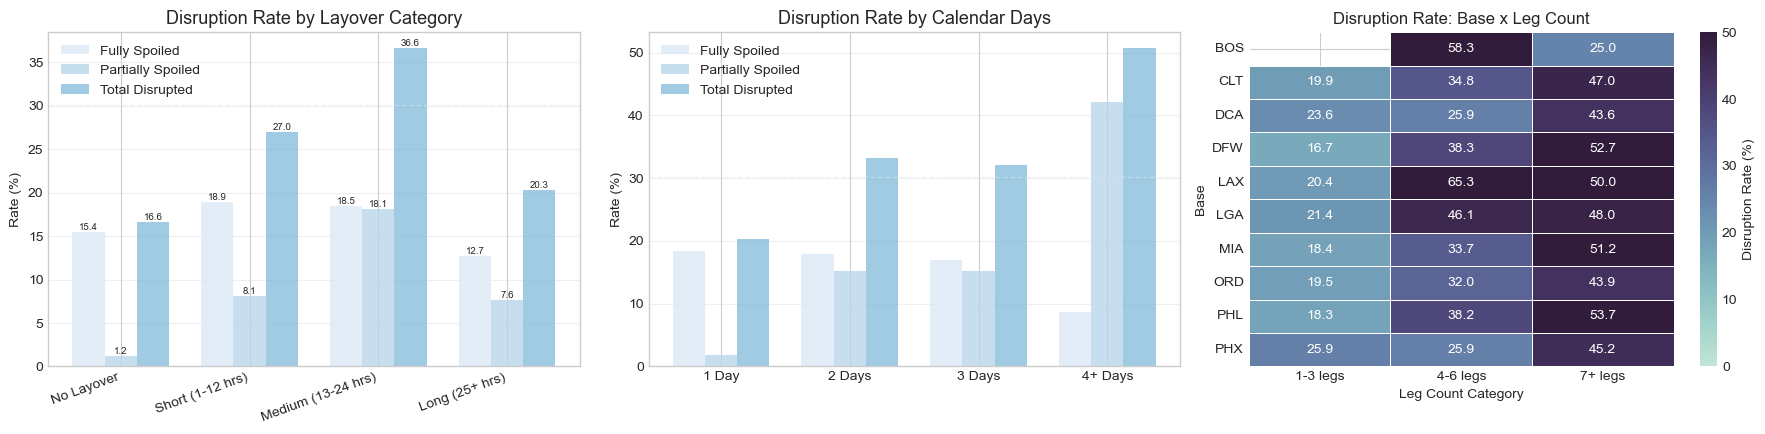

In [6]:
fig = plt.figure(figsize=(18, 12))

# Disruption by Layover Category
ax1 = plt.subplot(3, 3, 1)
x = np.arange(len(layover_stats))
width = 0.25

bars1 = ax1.bar(x - width, layover_stats['FullyDisruptedRate'], width, 
                label='Fully Spoiled', alpha=0.8)
bars2 = ax1.bar(x, layover_stats['PartiallyDisruptedRate'], width, 
                label='Partially Spoiled', alpha=0.8)
bars3 = ax1.bar(x + width, layover_stats['DisruptionRate'], width, 
                label='Total Disrupted', alpha=0.8)

ax1.set_ylabel('Rate (%)', )
ax1.set_title('Disruption Rate by Layover Category', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(layover_stats['LayoverCategory'], rotation=20, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=df['IsDisrupted'].mean() * 100, linestyle='--', linewidth=1, alpha=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.1f}', ha='center', va='bottom', fontsize=7)

# Disruption by Calendar Days
ax2 = plt.subplot(3, 3, 2)
x = np.arange(len(cal_days_stats))
bars1 = ax2.bar(x - width, cal_days_stats['FullyDisruptedRate'], width, 
                label='Fully Spoiled', alpha=0.8)
bars2 = ax2.bar(x, cal_days_stats['PartiallyDisruptedRate'], width, 
                label='Partially Spoiled', alpha=0.8)
bars3 = ax2.bar(x + width, cal_days_stats['DisruptionRate'], width, 
                label='Total Disrupted', alpha=0.8)

ax2.set_ylabel('Rate (%)', )
ax2.set_title('Disruption Rate by Calendar Days', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(cal_days_stats['CalDaysCategory'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=df['IsDisrupted'].mean() * 100, linestyle='--', linewidth=1, alpha=0.5)

# Heatmap of Base x Leg Count
ax3 = plt.subplot(3, 3, 3)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True), 
            cbar_kws={'label': 'Disruption Rate (%)'}, ax=ax3, vmin=0, vmax=50,
            linewidths=0.5, linecolor='white')
ax3.set_title('Disruption Rate: Base x Leg Count', fontsize=12)
ax3.set_xlabel('Leg Count Category')
ax3.set_ylabel('Base')

plt.tight_layout()

for _, row in layover_stats.iterrows():
    print(f"{row['LayoverCategory']:20s}: {row['DisruptionRate']:5.1f}% ({int(row['Total']):,} sequences)")

for _, row in cal_days_stats.iterrows():
    print(f"{row['CalDaysCategory']:10s}: {row['DisruptionRate']:5.1f}% ({int(row['Total']):,} sequences)")